In [2]:
import pandas as pd

# load the dataset
df = pd.read_csv('../data/raw/Suicide_Detection.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()


Shape: (232074, 3)

Columns: ['Unnamed: 0', 'text', 'class']

First few rows:


,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


In [3]:
# drop the unnamed index column
df = df.drop(columns=['Unnamed: 0'])

# check for nulls
print("Null values:")
print(df.isnull().sum())

# label distribution
print(f"\nLabel distribution:")
print(df['class'].value_counts())
print(f"\nLabel balance (%):")
print(df['class'].value_counts(normalize=True).round(3) * 100)

# text length stats
df['text_length'] = df['text'].str.len()
print(f"\nText length stats:")
print(df['text_length'].describe().round(0))

Null values:
text     0
class    0
dtype: int64

Label distribution:
class
suicide        116037
non-suicide    116037
Name: count, dtype: int64

Label balance (%):
class
suicide        50.0
non-suicide    50.0
Name: proportion, dtype: float64

Text length stats:
count    232074.0
mean        690.0
std        1156.0
min           3.0
25%         138.0
50%         315.0
75%         801.0
max       40297.0
Name: text_length, dtype: float64


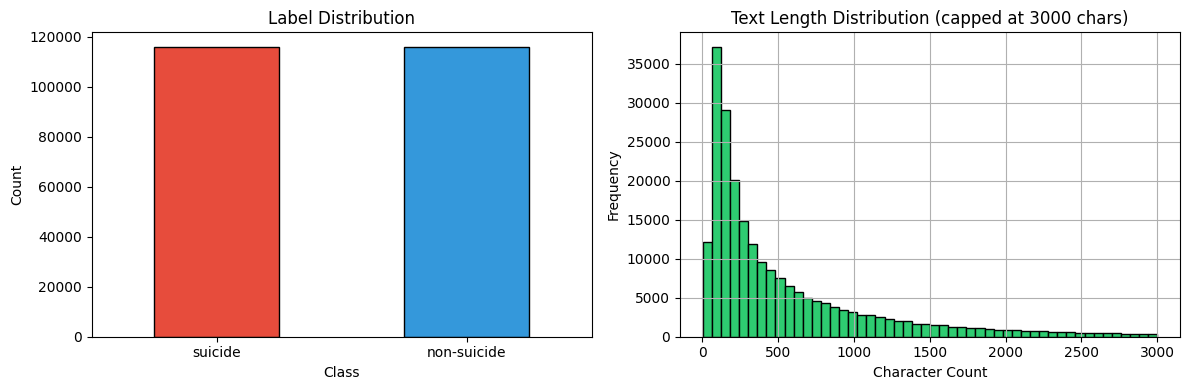

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# label distribution
df['class'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'], edgecolor='black')
axes[0].set_title('Label Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# text length distribution (cap at 3000 for readability)
df[df['text_length'] <= 3000]['text_length'].hist(bins=50, ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('Text Length Distribution (capped at 3000 chars)')
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../results/eda_plots.png', dpi=150)
plt.show()